<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://sigmoidal.ai/wp-content/uploads/2024/09/Academia-Sigmoidal-Light.png" alt="Academia Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
<h1 style="color: #007bff; margin: 0; font-size: 24px;">Pós-Graduação em Visão Computacional</h1>
    </div>
</div>
<hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
<h3 style="color: #343a40; margin: 0; font-size: 20px;"><strong>VIS101: Fundamentos da Visão Computacional</strong></h3>
<p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Instrutor:</strong> Carlos Melo, MSc.</p>
</div>

# Anotações com Supervision

No notebook anterior, retângulos, círculos e textos foram desenhados um a um com o OpenCV: coordenadas à mão, cor à mão, espessura à mão. Funciona, mas não escala. Quando um detector encontra dezenas de objetos por quadro, ninguém escreve um `cv2.rectangle` por objeto.

A biblioteca **supervision**, da Roboflow, resolve exatamente essa camada: recebe as detecções de qualquer modelo e cuida do desenho com uma linha. Nesta aula ela é usada com um detector pronto, treinado no dataset COCO, sem nenhum treinamento da nossa parte.

In [1]:
%pip install -q ultralytics supervision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import cv2
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO

print(sv.__version__)

0.29.1


## Um detector pronto

O modelo **YOLO11 nano** já sai de fábrica reconhecendo 80 categorias de objetos do dia a dia (pessoa, carro, cachorro, celular). O funcionamento interno do detector fica para a disciplina de Deep Learning; hoje ele é apenas uma caixa que devolve detecções.

In [3]:
model = YOLO('yolo26n.pt',)

img = cv2.imread('../imgs/panorama2.png')
results = model(img, verbose=False)[0]

## O objeto Detections

A ponte entre o detector e o desenho é o `sv.Detections`. Ele guarda, para cada objeto encontrado, a caixa (`xyxy`), a confiança e a classe, num formato único que a supervision entende independente do modelo de origem.

In [4]:
detections = sv.Detections.from_ultralytics(results)
detections

Detections(xyxy=array([[     483.45,      201.56,      1038.7,      555.61],
       [     1.0395,       500.1,       420.7,      947.94],
       [     905.84,      765.85,        1264,      921.67],
       [     905.84,      765.85,        1264,      921.67]], dtype=float32), mask=None, confidence=array([    0.85874,     0.71533,      0.3297,     0.29411], dtype=float32), class_id=array([62, 63, 66, 73]), tracker_id=None, data={'class_name': array(['tv', 'laptop', 'keyboard', 'book'], dtype='<U8')}, metadata={})

In [ ]:
print(detections.xyxy)
print(detections.confidence)
print(detections['class_name'])

[[      649.5      276.53       773.4       658.8]
 [     208.46      274.16      305.69      526.97]
 [     744.97      537.92      923.44      666.81]
 [     948.56      587.91      1056.4      666.95]
 [     790.15      316.68      882.08      563.22]
 [     961.22      294.37      1009.7      448.82]
 [     70.772       277.8       113.7       418.3]
 [     889.14      299.98      933.23      447.96]
 [     1101.1      291.92      1178.1      465.77]
 [     496.67      277.01      540.14      406.22]
 [     28.842      280.51      60.197      381.79]
 [     297.29      272.93      332.78      418.75]]
[    0.89853     0.86715     0.83239     0.77517     0.74728     0.66991     0.56684     0.50667     0.50469     0.37076     0.28674     0.27482]
['person' 'person' 'dog' 'dog' 'person' 'person' 'person' 'person' 'person' 'person' 'person' 'person']


Repare no formato da caixa: os mesmos quatro números `(x1, y1, x2, y2)` que foram passados manualmente ao `cv2.rectangle` no notebook anterior. A diferença é que agora quem os produz é o detector.

## Desenhando as caixas

O `sv.BoxAnnotator` desenha todas as caixas de uma vez. Um detalhe de versão importante: em tutoriais antigos o `BoxAnnotator` também escrevia o rótulo, mas na API atual ele desenha **apenas a caixa**; o texto é responsabilidade de outro annotator.

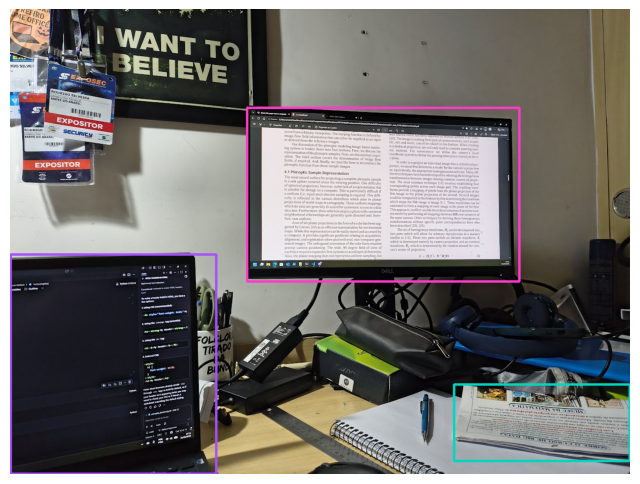

In [5]:
box_annotator = sv.BoxAnnotator(thickness=3)

anotada = box_annotator.annotate(scene=img.copy(), detections=detections)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(anotada, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Rótulos com classe e confiança

O `sv.LabelAnnotator` escreve o texto de cada detecção. Os rótulos são montados com uma list comprehension sobre a classe e a confiança, o mesmo papel do `cv2.putText` de antes.

In [6]:
labels = [
    f'{classe} {conf:.2f}'
    for classe, conf in zip(detections['class_name'], detections.confidence)
]
print(labels)

['tv 0.86', 'laptop 0.72', 'keyboard 0.33', 'book 0.29']


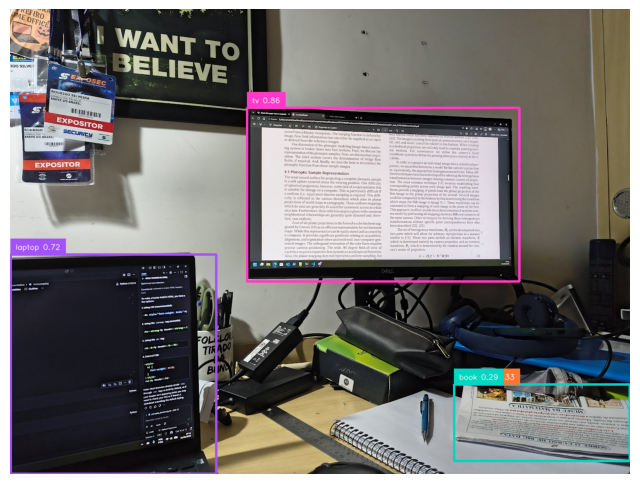

In [7]:
label_annotator = sv.LabelAnnotator()

anotada = label_annotator.annotate(scene=anotada, detections=detections, labels=labels)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(anotada, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Trocando o estilo sem tocar na detecção

A separação entre detecção e desenho rende de graça uma família inteira de estilos: caixas arredondadas, cantos, círculos, blur de privacidade. A detecção é a mesma; só o annotator muda.

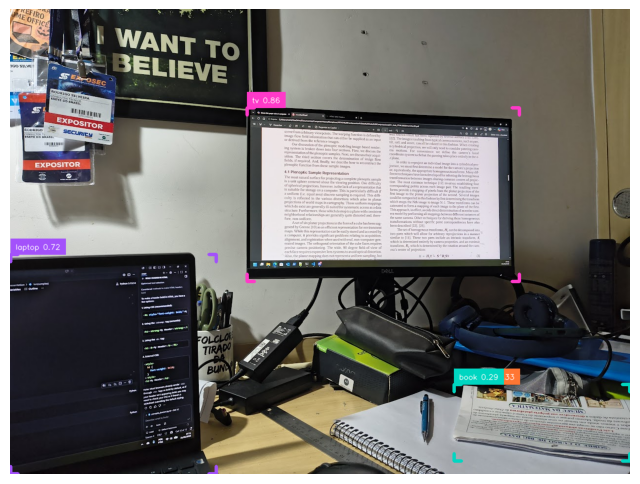

In [8]:
corner_annotator = sv.BoxCornerAnnotator(thickness=6)

estilizada = corner_annotator.annotate(scene=img.copy(), detections=detections)
estilizada = label_annotator.annotate(scene=estilizada, detections=detections, labels=labels)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(estilizada, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## De imagem para vídeo

Vídeo é uma sequência de imagens, e a supervision traz vídeos de exemplo prontos no módulo `assets`, o que evita depender de upload em plena aula.

In [ ]:
from supervision.assets import download_assets, VideoAssets

caminho = download_assets(VideoAssets.PEOPLE_WALKING)
print(caminho)

[2026-07-09 22:21:42] [INFO] supervision.assets.downloader - Downloading people-walking.mp4 assets


100%|██████████| 7.25M/7.25M [00:02<00:00, 3.29MB/s]

people-walking.mp4


## Rastreamento: dando identidade às detecções

Detectar quadro a quadro não diz que o pedestre do quadro 10 é o mesmo do quadro 11. Quem costura as detecções no tempo é o **tracker**. O `sv.ByteTrack` atribui um `tracker_id` a cada objeto, e o `sv.TraceAnnotator` desenha o rastro do caminho percorrido.

In [10]:
tracker = sv.ByteTrack()
trace_annotator = sv.TraceAnnotator()
box_video = sv.BoxAnnotator()
label_video = sv.LabelAnnotator()

In [11]:
def callback(frame, indice):
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update_with_detections(detections)
    labels = [f'#{t}' for t in detections.tracker_id]
    anotado = box_video.annotate(frame.copy(), detections=detections)
    anotado = trace_annotator.annotate(anotado, detections=detections)
    return label_video.annotate(anotado, detections=detections, labels=labels)

A próxima célula roda o detector em todos os quadros do vídeo. Com o runtime de GPU do Colab são alguns segundos; na CPU, o mesmo trabalho leva alguns minutos.

In [20]:
caminho = "../videos/" + caminho
caminho

'../videos/people-walking.mp4'

In [21]:
sv.process_video(
    source_path=caminho,
    target_path='../videos/people-walking-anotado.mp4',
    callback=callback,
)

O `process_video` percorre o vídeo inteiro aplicando o `callback` em cada quadro e grava o resultado. Um quadro do meio serve de conferência:

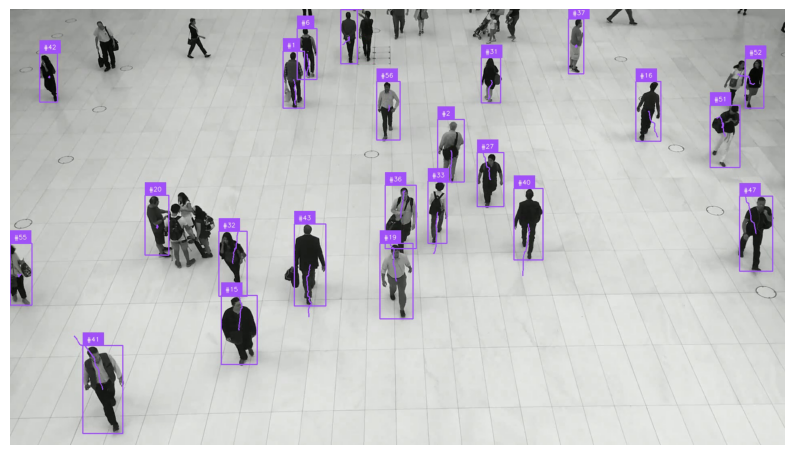

In [22]:
cap = cv2.VideoCapture('../videos/people-walking-anotado.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## Síntese

A gramática visual é a mesma do notebook anterior: caixa, rótulo, traço. O que mudou foi quem faz o trabalho. Com o OpenCV cada marca foi desenhada à mão; com a supervision, o detector produz as coordenadas e os annotators desenham tudo de uma vez, em imagem ou em vídeo, com rastreamento por identidade. Essa separação entre detectar e desenhar é o padrão dos sistemas reais de visão computacional.